# Mini Project 1: Comparing Word Use in Children's Fantasy Novels

## Research Question

How consistent is word usage across two books by Lewis Carroll and two books by L. Frank Baum, and which words distinguish the two authors?

## Texts

I will use four books from Project Gutenberg:

- Lewis Carroll, *Alice's Adventures in Wonderland*
- Lewis Carroll, *Through the Looking-Glass*
- L. Frank Baum, *The Wonderful Wizard of Oz*
- L. Frank Baum, *The Marvelous Land of Oz*

The two books by each writer will provide same-author comparisons, while comparing the Carroll books with the Baum books will provide comparisons between authors. These books are all children's fantasy novels, which helps reduce differences caused by comparing unrelated genres.

## Hypothesis

I expect books by the same author to have more similar word-frequency patterns than books by different authors. I also expect content words to reflect each story's characters and setting, while common function words may show more consistent differences in the authors' writing styles.

## Load and Clean the Texts

The books were downloaded as plain-text files from Project Gutenberg. The code below removes the Gutenberg header and footer, converts the text to lowercase, and separates it into words.

In [1]:
from pathlib import Path
import re
from collections import Counter

book_files = {
    "Alice's Adventures in Wonderland": Path("books/alice's  adventures in wonderland.txt"),
    "Through the Looking-Glass": Path("books/through-the-looking-glass.txt"),
    "The Wonderful Wizard of Oz": Path("books/the wonderful wizard of oz.txt"),
    "The Marvelous Land of Oz": Path("books/marvelous land of oz.txt"),
}

authors = {
    "Alice's Adventures in Wonderland": "Lewis Carroll",
    "Through the Looking-Glass": "Lewis Carroll",
    "The Wonderful Wizard of Oz": "L. Frank Baum",
    "The Marvelous Land of Oz": "L. Frank Baum",
}

def remove_gutenberg_boilerplate(text):
    start = re.search(r"\*\*\* START OF (?:THIS|THE) PROJECT GUTENBERG EBOOK.*?\*\*\*", text, re.IGNORECASE)
    end = re.search(r"\*\*\* END OF (?:THIS|THE) PROJECT GUTENBERG EBOOK.*?\*\*\*", text, re.IGNORECASE)
    start_position = start.end() if start else 0
    end_position = end.start() if end else len(text)
    return text[start_position:end_position]

def tokenize(text):
    text = text.lower().replace("’", "'")
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text)

texts = {
    title: remove_gutenberg_boilerplate(path.read_text(encoding="utf-8-sig"))
    for title, path in book_files.items()
}
tokens = {title: tokenize(text) for title, text in texts.items()}
word_counts = {title: Counter(words) for title, words in tokens.items()}

In [2]:
for title in book_files:
    print(f"{title}: {len(tokens[title]):,} words")

Alice's Adventures in Wonderland: 26,776 words
Through the Looking-Glass: 30,153 words
The Wonderful Wizard of Oz: 39,767 words
The Marvelous Land of Oz: 42,402 words


## Word-Frequency Analysis

Because the books have different lengths, the comparisons use occurrences per 10,000 words instead of raw counts. First, common English stop words are removed to make the main content words easier to see.

In [3]:
stop_words = set("""
a about after again all am an and any are as at be because been before being
between both but by can could did do does doing down during each few for from
further had has have having he her here hers herself him himself his how i if
in into is it its itself just me more most my myself no nor not now of off on
once only or other our ours ourselves out over own same she should so some such
than that the their theirs them themselves then there these they this those
through to too under until up very was we were what when where which while who
whom why will with would you your yours yourself yourselves
""".split())

def frequency_per_10000(title, word):
    return word_counts[title][word] / len(tokens[title]) * 10000

def top_content_words(title, number=10):
    content_counts = Counter({
        word: count
        for word, count in word_counts[title].items()
        if word not in stop_words and len(word) > 1
    })
    return [
        (word, frequency_per_10000(title, word))
        for word, count in content_counts.most_common(number)
    ]

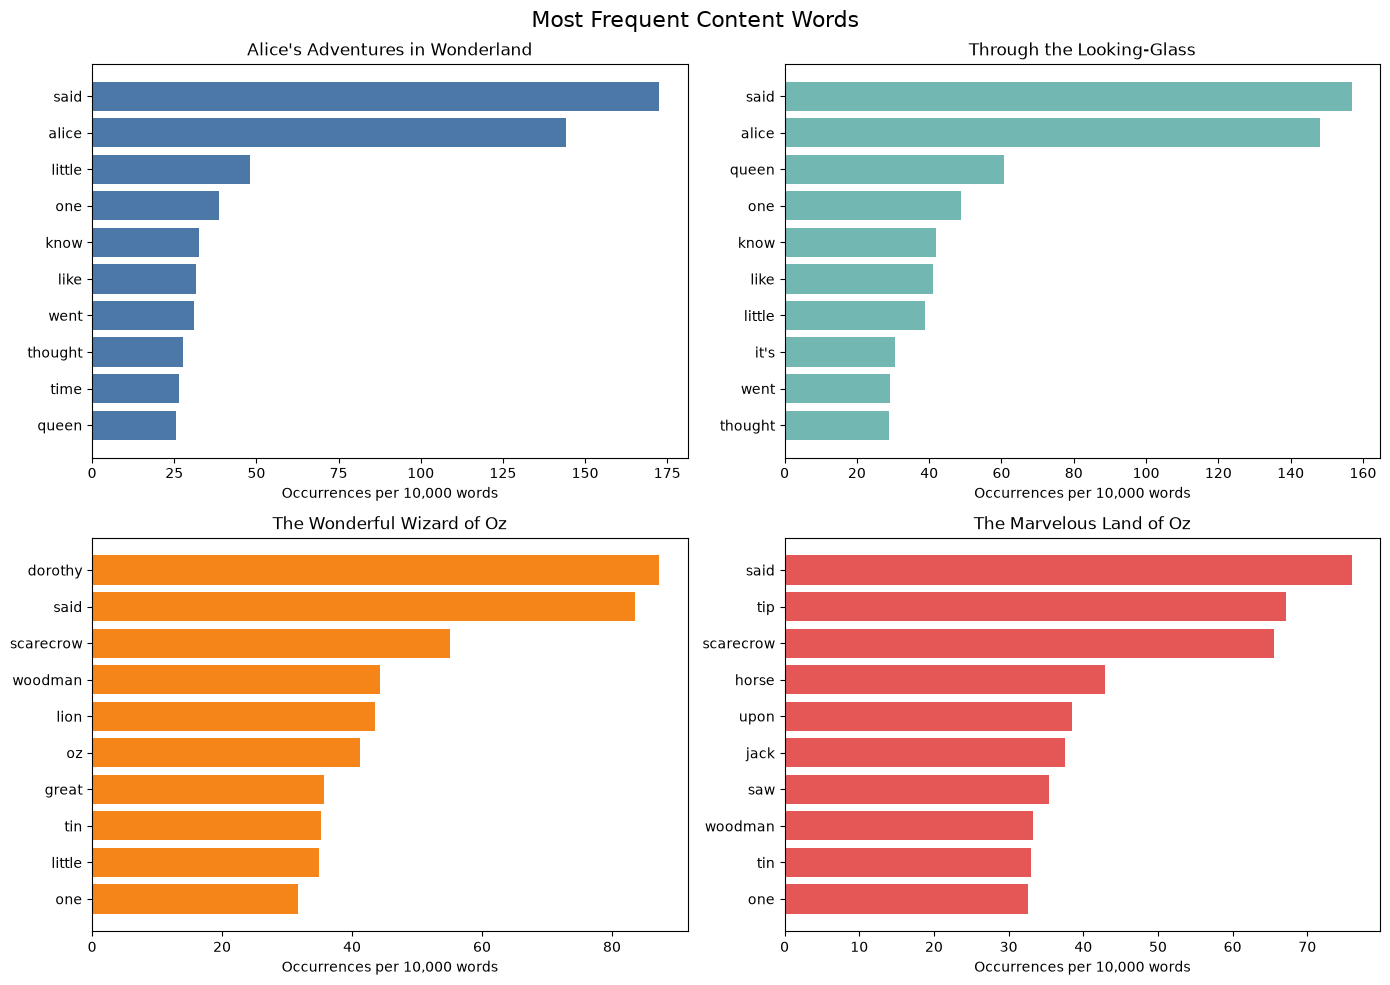

In [4]:
import matplotlib.pyplot as plt

colors = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for axis, title, color in zip(axes.flat, book_files, colors):
    top_words = top_content_words(title)
    words = [word for word, frequency in top_words][::-1]
    frequencies = [frequency for word, frequency in top_words][::-1]
    axis.barh(words, frequencies, color=color)
    axis.set_title(title)
    axis.set_xlabel("Occurrences per 10,000 words")

fig.suptitle("Most Frequent Content Words", fontsize=16)
plt.tight_layout()
plt.show()

## Function Words and Similarity

Function words carry little information about a story's subject, but their repeated use can reflect an author's writing style. The similarity score ranges from 0 to 1, with values closer to 1 indicating more similar frequency patterns.

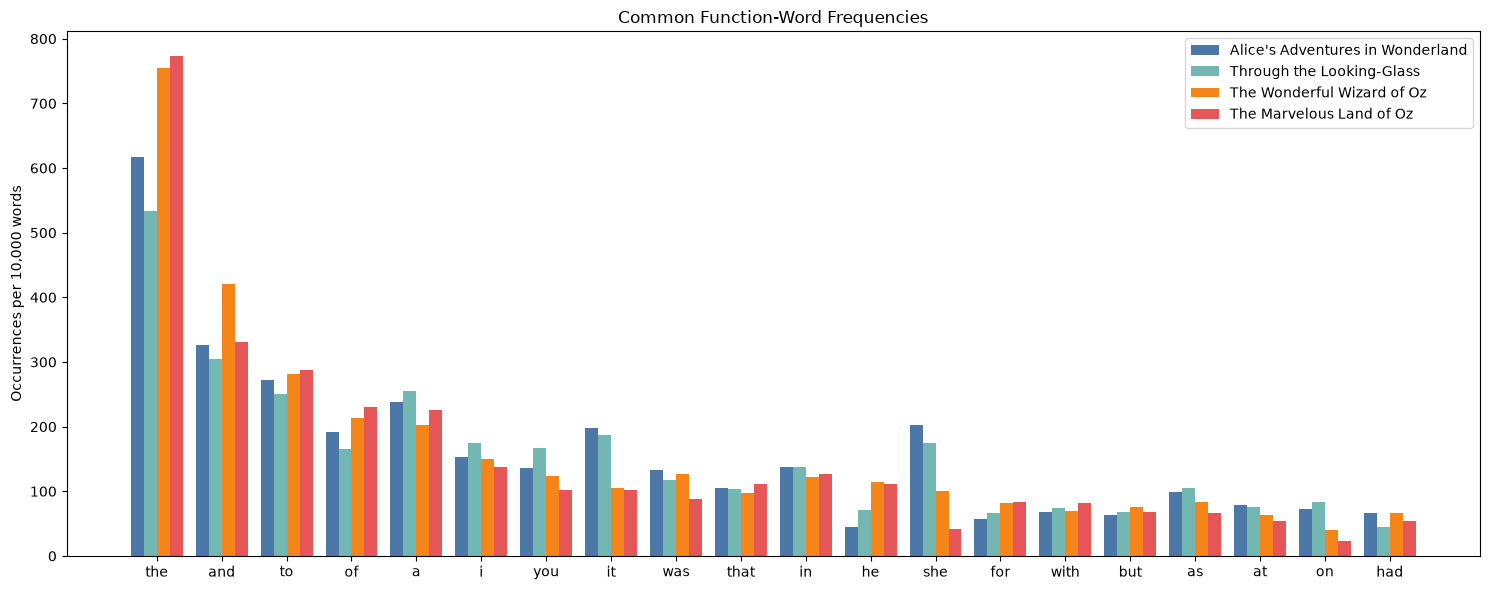

In [5]:
function_words = ["the", "and", "to", "of", "a", "i", "you", "it", "was", "that", "in", "he", "she", "for", "with", "but", "as", "at", "on", "had"]
positions = list(range(len(function_words)))
bar_width = 0.2
fig, axis = plt.subplots(figsize=(15, 6))

for index, (title, color) in enumerate(zip(book_files, colors)):
    center_offset = index - (len(book_files) - 1) / 2
    offsets = [position + center_offset * bar_width for position in positions]
    frequencies = [frequency_per_10000(title, word) for word in function_words]
    axis.bar(offsets, frequencies, width=bar_width, label=title, color=color)

axis.set_xticks(positions)
axis.set_xticklabels(function_words)
axis.set_ylabel("Occurrences per 10,000 words")
axis.set_title("Common Function-Word Frequencies")
axis.legend()
plt.tight_layout()
plt.show()

In [6]:
from math import sqrt

def function_word_similarity(first_title, second_title):
    first = [frequency_per_10000(first_title, word) for word in function_words]
    second = [frequency_per_10000(second_title, word) for word in function_words]
    numerator = sum(first_value * second_value for first_value, second_value in zip(first, second))
    denominator = sqrt(sum(value ** 2 for value in first)) * sqrt(sum(value ** 2 for value in second))
    return numerator / denominator

from itertools import combinations

titles = list(book_files)
book_pairs = combinations(titles, 2)
for first_title, second_title in book_pairs:
    score = function_word_similarity(first_title, second_title)
    comparison_type = "same author" if authors[first_title] == authors[second_title] else "different authors"
    print(f"{first_title} vs. {second_title}: {score:.3f} ({comparison_type})")

Alice's Adventures in Wonderland vs. Through the Looking-Glass: 0.995 (same author)
Alice's Adventures in Wonderland vs. The Wonderful Wizard of Oz: 0.976 (different authors)
Alice's Adventures in Wonderland vs. The Marvelous Land of Oz: 0.963 (different authors)
Through the Looking-Glass vs. The Wonderful Wizard of Oz: 0.966 (different authors)
Through the Looking-Glass vs. The Marvelous Land of Oz: 0.952 (different authors)
The Wonderful Wizard of Oz vs. The Marvelous Land of Oz: 0.993 (same author)


## Words That Differ Most Between the Authors

For the author comparison, the counts from each author's two books are combined. Positive values indicate more frequent use by Carroll, while negative values indicate more frequent use by Baum.

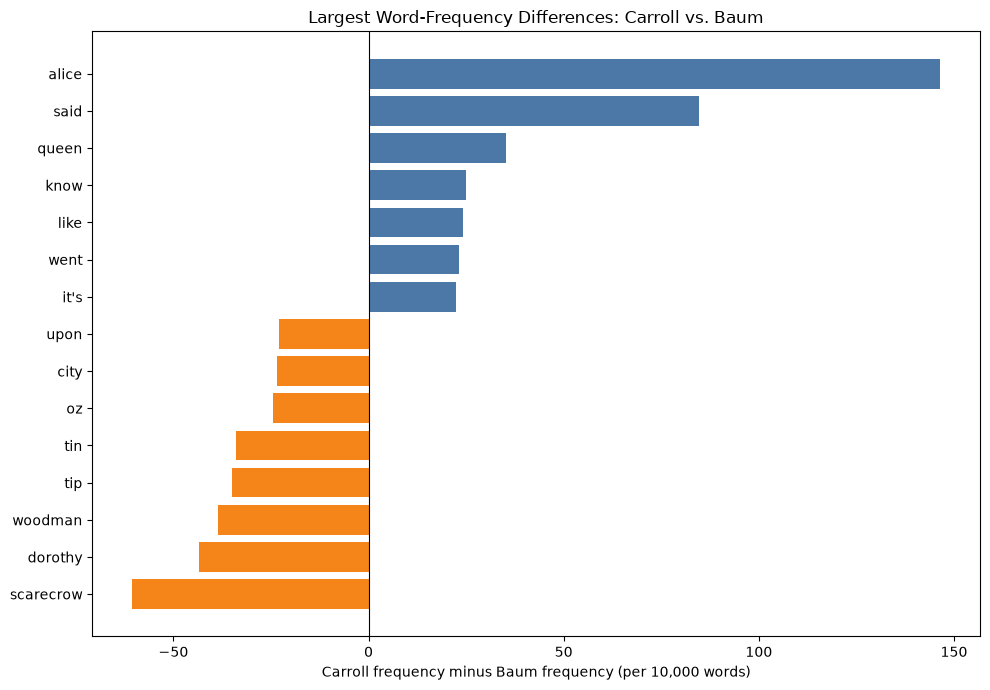

In [7]:
carroll_counts = word_counts[titles[0]] + word_counts[titles[1]]
carroll_total = len(tokens[titles[0]]) + len(tokens[titles[1]])
baum_counts = word_counts[titles[2]] + word_counts[titles[3]]
baum_total = len(tokens[titles[2]]) + len(tokens[titles[3]])

candidate_words = {
    word for word in carroll_counts.keys() | baum_counts.keys()
    if word not in stop_words
    and len(word) > 1
    and carroll_counts[word] + baum_counts[word] >= 10
}
differences = []
for word in candidate_words:
    carroll_frequency = carroll_counts[word] / carroll_total * 10000
    baum_frequency = baum_counts[word] / baum_total * 10000
    differences.append((word, carroll_frequency - baum_frequency))

largest_differences = sorted(differences, key=lambda item: abs(item[1]), reverse=True)[:15]
largest_differences.sort(key=lambda item: item[1])
words = [word for word, difference in largest_differences]
values = [difference for word, difference in largest_differences]
bar_colors = ["#4C78A8" if value > 0 else "#F58518" for value in values]

fig, axis = plt.subplots(figsize=(10, 7))
axis.barh(words, values, color=bar_colors)
axis.axvline(0, color="black", linewidth=0.8)
axis.set_xlabel("Carroll frequency minus Baum frequency (per 10,000 words)")
axis.set_title("Largest Word-Frequency Differences: Carroll vs. Baum")
plt.tight_layout()
plt.show()